# K-NN Classification

**Malignant or Benign classification**

In [178]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [179]:
# Loading the dataset
df = pd.read_csv(r"C:\Users\Yug\Downloads\bdiag.csv")
# Encoding the target variable
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


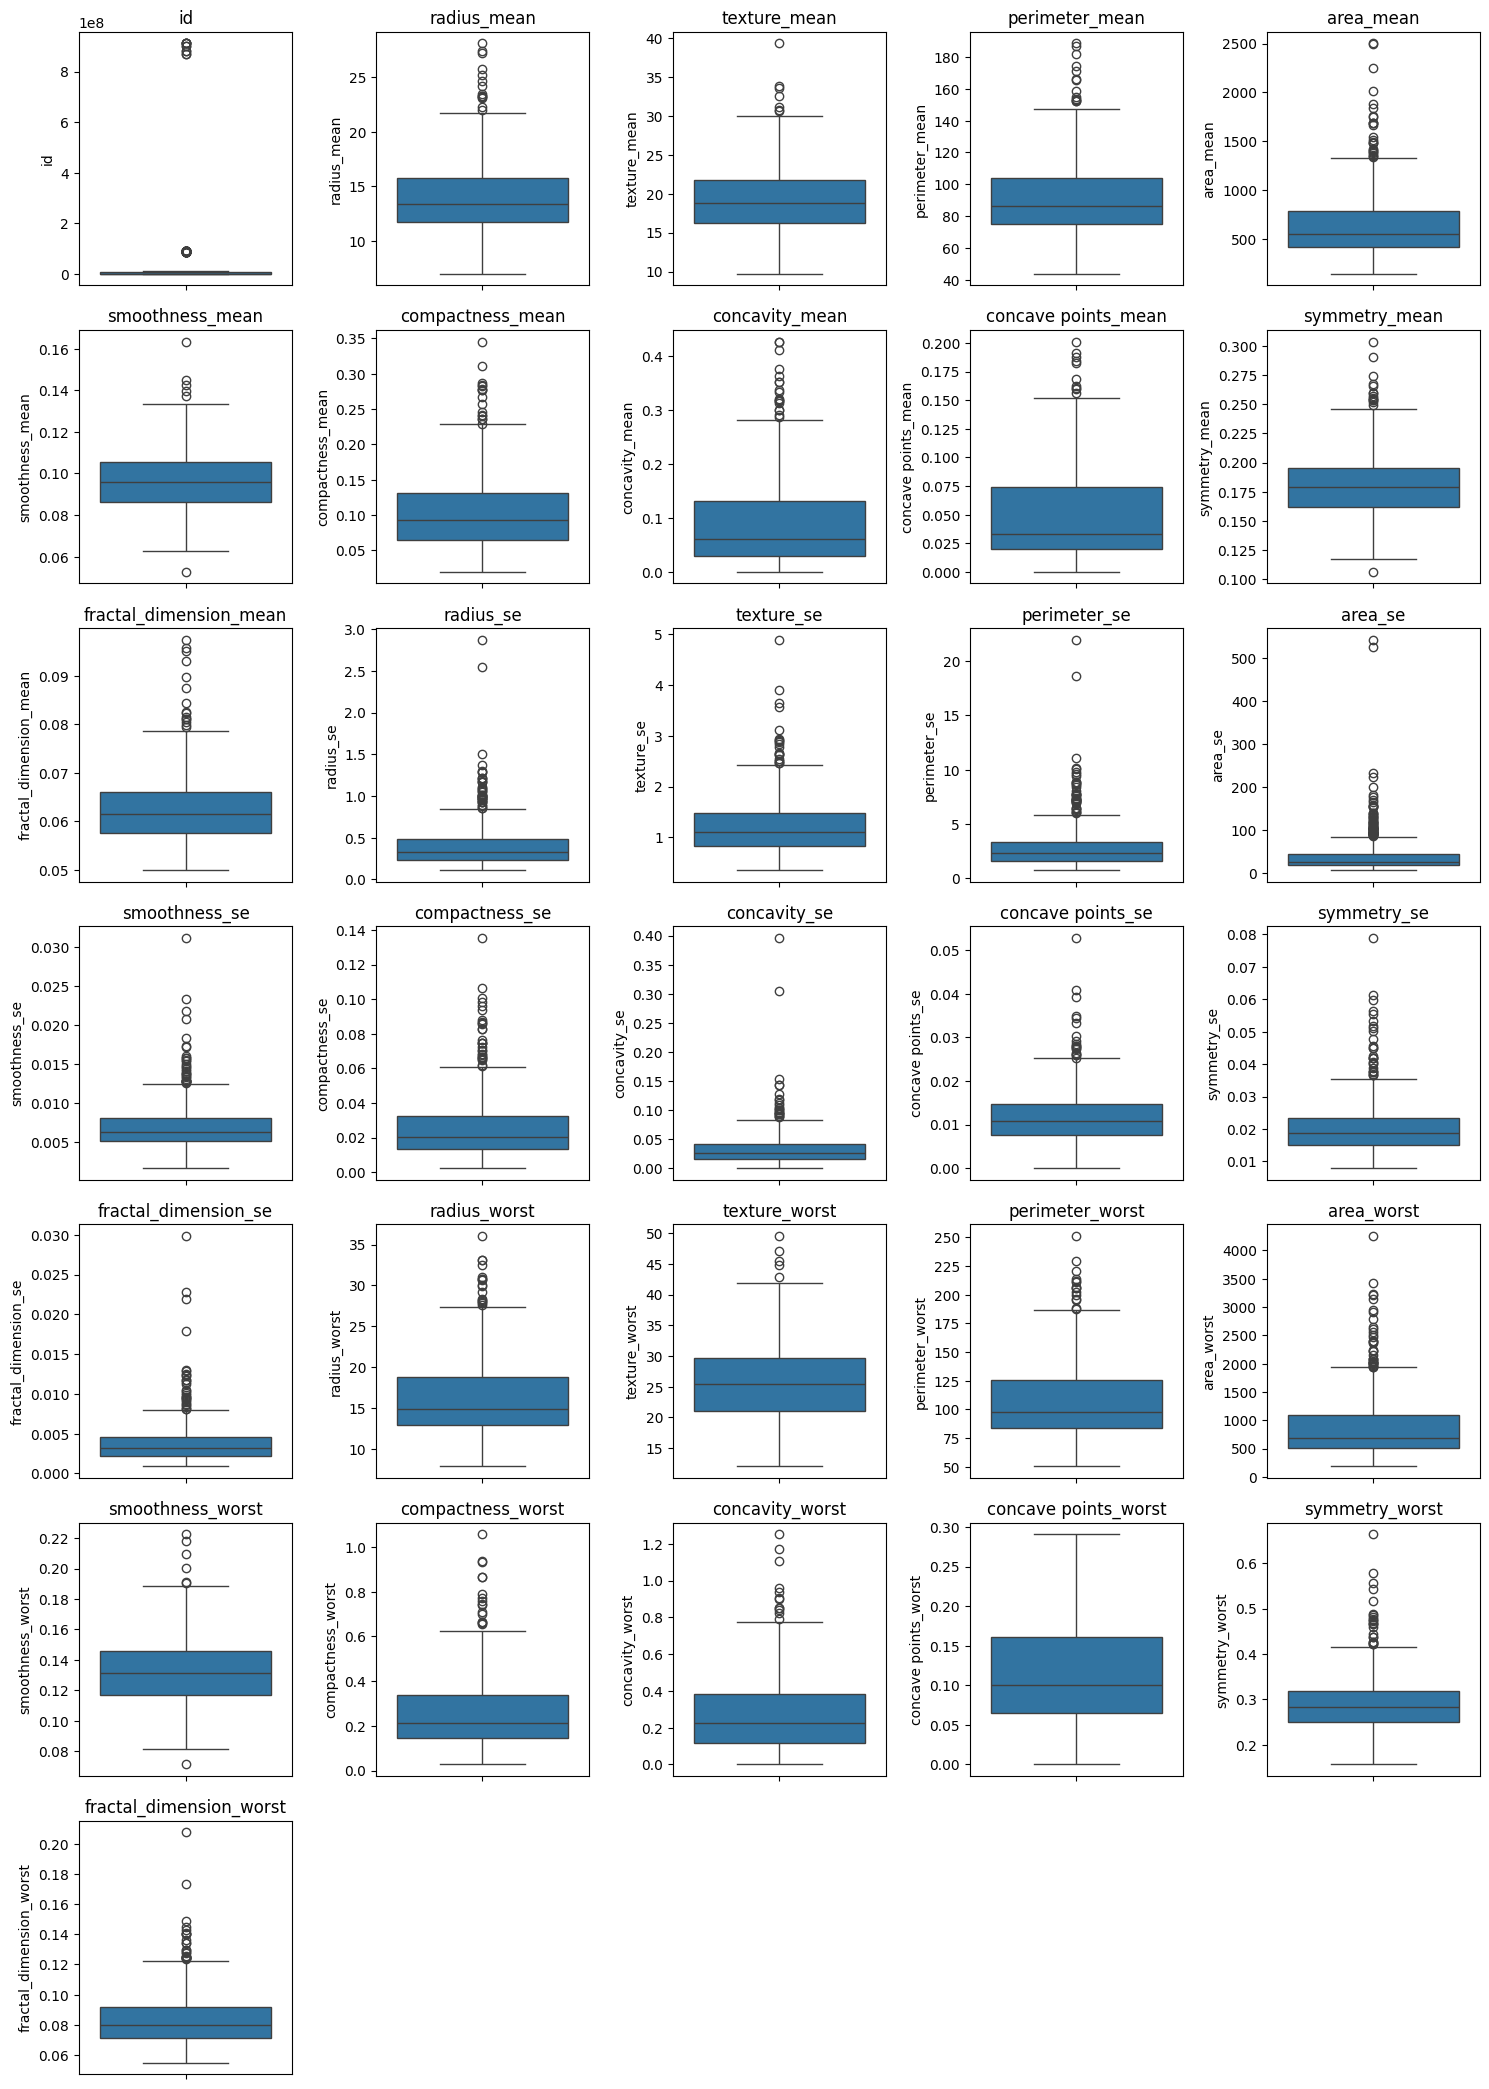

In [180]:
# Boxplots
features = df.drop('diagnosis', axis=1).columns
n_features = len(features)
cols = 5
rows = int(np.ceil(n_features / cols))
plt.figure(figsize=(cols * 3, rows * 3))
for i, feature in enumerate(features):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()

In [181]:
# IQR outlier removal for selected features
features = df[["texture_mean", "radius_mean"]]
Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Keep only rows within bounds
df_iqr = df[
    (df["texture_mean"] >= lower_bound["texture_mean"]) &
    (df["texture_mean"] <= upper_bound["texture_mean"]) &
    (df["radius_mean"] >= lower_bound["radius_mean"]) &
    (df["radius_mean"] <= upper_bound["radius_mean"])
]
print("Original size:", df.shape)
print("After IQR removal:", df_iqr.shape)

Original size: (569, 32)
After IQR removal: (548, 32)


In [182]:
# Splitting into X and y
X = df_iqr[['texture_mean', 'radius_mean']]
y = df_iqr['diagnosis']

In [183]:
# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=200, stratify=y
)

In [184]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [185]:
# KNN with K=5
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train, y_train)
y_pred_5 = knn5.predict(X_test)
print("Accuracy (k=5):", accuracy_score(y_test, y_pred_5))
print("Classification report: \n", classification_report(y_test, y_pred_5))

Accuracy (k=5): 0.9090909090909091
Classification report: 
               precision    recall  f1-score   support

           0       0.92      0.94      0.93        71
           1       0.89      0.85      0.87        39

    accuracy                           0.91       110
   macro avg       0.90      0.89      0.90       110
weighted avg       0.91      0.91      0.91       110



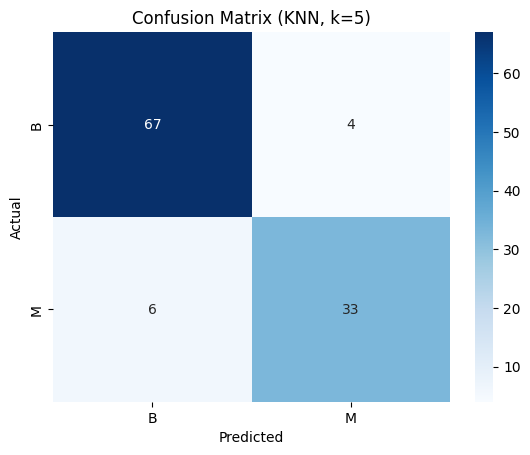

In [186]:
# Confusion Matrix at K=5
cm5 = confusion_matrix(y_test, y_pred_5)
sns.heatmap(
    cm5,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (KNN, k=5)")
plt.show()

In [187]:
# Decision boundary
def plot_decision_boundary(model, X, y, scaler, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
    plt.xlabel("texture_mean")
    plt.ylabel("radius_mean")
    plt.title(title)
    plt.show()

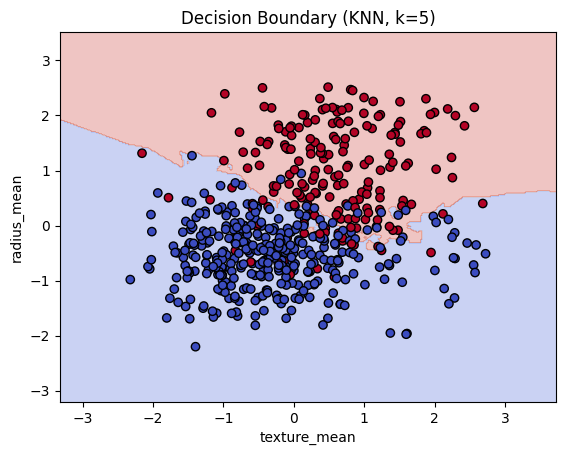

In [188]:
# Scatterplot (Decision boundary) at K=5
X_scaled = scaler.transform(X)
plot_decision_boundary(
    knn5,
    X_scaled,
    y,
    scaler,
    "Decision Boundary (KNN, k=5)"
)

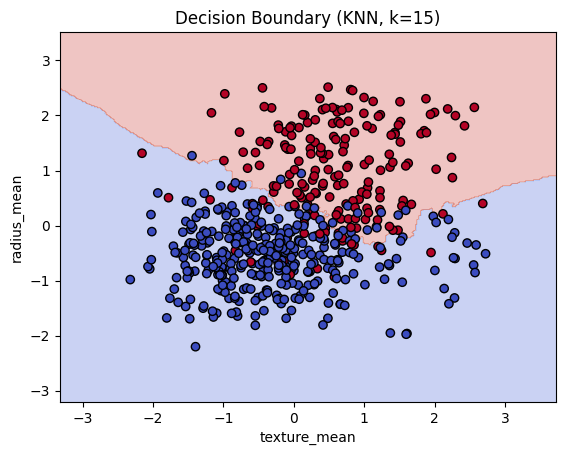

In [189]:
# Scatterplot (Decision boundary) at K=15
knn15 = KNeighborsClassifier(n_neighbors=15)
knn15.fit(X_train, y_train)
plot_decision_boundary(
    knn15,
    X_scaled,
    y,
    scaler,
    "Decision Boundary (KNN, k=15)"
)

## Conclusion / Inference

In this experiment, K-Nearest Neighbors (KNN) classification was applied to the breast cancer diagnostic dataset to classify tumors as benign or malignant using the features texture_mean and radius_mean. Exploratory Data Analysis was performed using boxplots to identify the presence of outliers across all features.

Outliers were handled leniently using the Interquartile Range (IQR) method with wider bounds to reduce the influence of extreme values while preserving important medical cases. Feature scaling was applied using StandardScaler, which is essential for distance-based algorithms such as KNN.

The KNN classifier with k = 5 achieved an accuracy of approximately 91%, and the confusion matrix showed good classification performance. Decision boundary visualizations indicated that the two classes are reasonably separable using the selected features. Increasing k to 15 resulted in a smoother decision boundary, demonstrating the effect of k on model generalization.

Overall, the results show that KNN is an effective classifier for this dataset when appropriate preprocessing steps such as scaling and careful outlier handling are applied.
